# Week 4: Logistic Regression and Feature Scaling
**Victor Vasquez Gil | Boston University**


## 1. Research Question

Can borrower and loan characteristics help identify Lending Club loans that will be charged off? Does scaling the features improve how logistic regression performs?

My capstone focuses on predicting credit risk. In my earlier work, I found that a model could perform reasonably well overall while still missing many charged off loans. This showed me why accuracy alone is not enough.

In Week 2, I used linear regression, ridge, lasso, and elastic net to predict interest rates. This week, I return to the main question in my capstone and predict repayment outcomes:

- **0 = Fully Paid**
- **1 = Charged Off**

I compare logistic regression without scaling, with standardization, and with min-max scaling. I also examine how changing the probability threshold affects the number of charged-off loans identified.

In [27]:
from pathlib import Path
import sys, json, time, warnings, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown, HTML
from threadpoolctl import threadpool_limits
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score, log_loss,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay)


In [28]:
SEED = 42
SAMPLE_SIZE = 50_000
CHUNK_SIZE = 25_000
CV_FOLDS = 5
MAX_ITER = 2_000
C_GRID = [0.01, 0.1, 1.0, 10.0]
DATA_PATH = Path("data/accepted_2007_to_2018Q4.csv.gz")  # Example: Path(r"C:\Users\Victor\Downloads\accepted_2007_to_2018Q4.csv.gz")
DATASET_VERSION = 3
SOURCE_NAME = "accepted_2007_to_2018Q4.csv.gz"
DATASET_URL = "https://www.kaggle.com/datasets/wordsforthewise/lending-club"
OUTPUT_DIR = Path("week4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
thread_limit = threadpool_limits(limits=1)

numeric_cols = ["loan_amnt", "annual_inc", "dti", "fico_range_low", "open_acc",
    "pub_rec", "revol_bal", "revol_util", "total_acc", "delinq_2yrs", "inq_last_6mths"]
categorical_cols = ["term", "home_ownership", "purpose", "emp_length"]
features = numeric_cols + categorical_cols
BLUE, TEAL, ORANGE, GRAY = "#315F91", "#137C8B", "#B85C20", "#6B7280"
sns.set_theme(style="whitegrid", rc={"figure.dpi": 125, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False, "grid.alpha": 0.25})

def show_table(frame, decimals=3):
    formatters = {c: (lambda v: f"{v:,.{decimals}f}") for c in frame.select_dtypes(include="floating").columns}
    display(HTML('<style>.week4-table {border-collapse:collapse;font-family:system-ui;font-size:13px;} '
        '.week4-table th {background:#172B4D;color:white;padding:8px;} '
        '.week4-table td {padding:8px;border-bottom:1px solid #ddd;} '
        '.week4-table tr:nth-child(even) {background:#f3f6f8;}</style>' +
        frame.to_html(index=False, border=0, classes="week4-table", formatters=formatters)))

def finish(fig, filename):
    fig.savefig(OUTPUT_DIR / (filename + ".png"), dpi=180, bbox_inches="tight")
    plt.show()

def clean_number(s):
    values = s.astype("string").str.strip().str.replace(",", "", regex=False).str.replace("%", "", regex=False)
    return pd.to_numeric(values, errors="coerce").astype(float).replace([np.inf, -np.inf], np.nan)


## 2. Data and Feature Selection

I use the accepted loans file from version 3 of the Lending Club dataset.

**Source reference:**  
https://www.kaggle.com/datasets/wordsforthewise/lending-club

The URL is included as a reference. The notebook reads an existing local CSV or CSV.GZ file and does not download the dataset.

I keep a random sample of 50,000 loans labeled Fully Paid or Charged Off. Current, late, and other statuses are excluded from this comparison. I use a random seed of 42 to make the sampling repeatable.

The predictors include loan amount, income, debt-to-income ratio, origination FICO, credit history, loan term, home ownership, employment length, and loan purpose.

I exclude information recorded after the loan was issued, such as payments, recoveries, and later credit scores. These fields could reveal the outcome and make the model appear more accurate than it would be when evaluating a new loan.

I also leave out interest rate, grade, subgrade, and installment to keep the main feature set consistent with Week 2.

This dataset includes accepted loans only. The results do not describe rejected applicants, and filtering for resolved outcomes may underrepresent newer loans.

In [29]:
DATA_PATH = Path(
    "/home/codespace/.cache/kagglehub/datasets/wordsforthewise/"
    "lending-club/versions/3/accepted_2007_to_2018Q4.csv.gz"
)

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"The dataset was not found at:\n{DATA_PATH}\n"
        "Check that the existing file is still available."
    )

print("Using existing dataset:", DATA_PATH)

# 2. Check the required columns

# These settings and functions come from the earlier setup cells:
# features, SEED, CHUNK_SIZE, SAMPLE_SIZE, OUTPUT_DIR, show_table

header = pd.read_csv(DATA_PATH, nrows=0)

required = features + ["loan_status"]

missing = sorted(set(required) - set(header.columns))

if missing:
    raise ValueError(
        f"Missing required columns: {missing}. "
        "Use the Lending Club accepted-loans file."
    )

optional_columns = [
    column
    for column in ["id", "member_id", "issue_d"]
    if column in header.columns
]

read_cols = list(dict.fromkeys(required + optional_columns))


# 3. Read in batches and sample eligible loans

rng = np.random.default_rng(SEED)

sample = None
rows_scanned = 0
eligible_count = 0
status_counts = pd.Series(dtype="int64")

with pd.read_csv(
    DATA_PATH,
    usecols=read_cols,
    chunksize=CHUNK_SIZE,
    dtype="string",
    low_memory=False,
) as reader:

    for batch_number, chunk in enumerate(reader, start=1):

        # Zero-based source row number, excluding the CSV header.
        chunk["source_row"] = np.arange(
            rows_scanned,
            rows_scanned + len(chunk),
        )

        rows_scanned += len(chunk)

        chunk["loan_status"] = chunk["loan_status"].str.strip()

        # Count every source status before filtering.
        batch_status_counts = (
            chunk["loan_status"]
            .fillna("Missing status")
            .value_counts()
        )

        status_counts = status_counts.add(
            batch_status_counts,
            fill_value=0,
        )

        # Keep only the two outcomes used for classification.
        chunk = chunk.loc[
            chunk["loan_status"].isin(["Fully Paid", "Charged Off"])
        ].copy()

        eligible_count += len(chunk)

        if not chunk.empty:

            # Keep a uniform random sample across all eligible rows.
            chunk["_priority"] = rng.random(len(chunk))

            if sample is None:
                sample = chunk
            else:
                sample = pd.concat(
                    [sample, chunk],
                    ignore_index=True,
                )

            sample = sample.nsmallest(
                SAMPLE_SIZE,
                "_priority",
            )

        if batch_number % 20 == 0:
            print(
                f"Scanned {rows_scanned:,} rows | "
                f"Eligible loans: {eligible_count:,}"
            )



# 4. Finalize the sample

if sample is None or len(sample) < 100:
    raise ValueError(
        "Too few eligible loans were found. Check that loan_status "
        "contains 'Fully Paid' and 'Charged Off'."
    )

loans = (
    sample
    .drop(columns="_priority")
    .reset_index(drop=True)
)

del sample

if len(loans) < SAMPLE_SIZE:
    print(
        f"Only {len(loans):,} eligible loans were available; "
        f"the requested sample size was {SAMPLE_SIZE:,}."
    )


# 5. Check available loan and borrower identifiers

for key in ["id", "member_id"]:

    if key not in loans.columns:
        print(
            f"No {key} column: independence cannot be fully checked."
        )
        continue

    identifiers = (
        loans[key]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .dropna()
    )

    if identifiers.empty:
        print(
            f"No usable {key}: independence cannot be fully checked."
        )

    elif identifiers.duplicated().any():
        raise ValueError(
            f"Repeated {key} values were found in the sample. "
            "Review duplicate loans or use borrower-aware splitting "
            "before continuing."
        )

    else:
        print(
            f"No duplicate observed {key} values in the sample."
        )


# 6. Display and save the sampling summary

sampling_summary = pd.DataFrame({
    "Stage": [
        "All source rows",
        "Fully Paid or Charged Off",
        "Sample retained",
    ],
    "Loans": [
        rows_scanned,
        eligible_count,
        len(loans),
    ],
})

source_status_summary = (
    status_counts
    .astype("int64")
    .rename_axis("Source status")
    .reset_index(name="Loans")
    .sort_values("Loans", ascending=False)
    .reset_index(drop=True)
)

show_table(sampling_summary, 0)
show_table(source_status_summary, 0)

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sampling_summary.to_csv(
    OUTPUT_DIR / "sampling_summary.csv",
    index=False,
)

source_status_summary.to_csv(
    OUTPUT_DIR / "source_status_counts.csv",
    index=False,
)

print(
    f"\nReady: {len(loans):,} sampled loans. "
    "Continue to the feature preparation and splitting cell."
)

Using existing dataset: /home/codespace/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3/accepted_2007_to_2018Q4.csv.gz
Scanned 500,000 rows | Eligible loans: 391,164
Scanned 1,000,000 rows | Eligible loans: 571,474
Scanned 1,500,000 rows | Eligible loans: 901,814
Scanned 2,000,000 rows | Eligible loans: 1,229,836
No duplicate observed id values in the sample.
No usable member_id: independence cannot be fully checked.


Stage,Loans
All source rows,2260701
Fully Paid or Charged Off,1345310
Sample retained,50000


Source status,Loans
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40
Missing status,33



Ready: 50,000 sampled loans. Continue to the feature preparation and splitting cell.


## 3. Splitting the Data

I divide the sample into three groups:

| Split | Loans | Purpose |
|---|---:|---|
| Training | 30,000 | Explore the data and compare model settings |
| Validation | 10,000 | Choose the probability threshold |
| Test | 10,000 | Evaluate the final model |

Both splits are stratified to keep the charged-off share similar across groups.

Within the training set, I use five-fold stratified cross-validation. Missing-value replacement, categorical encoding, and scaling are fitted separately inside each training fold.

The test set stays separate until the model settings and threshold have been selected. This prevents test results from influencing those decisions.

Because the split is random, it does not show how well the model would perform on loans issued in a later period.

In [30]:
X = loans[features].copy()
for col in numeric_cols:
    X[col] = clean_number(X[col])
for col in categorical_cols:
    values = X[col].str.strip().replace("", pd.NA)
    X[col] = values.astype(object).where(values.notna(), np.nan)
y = loans["loan_status"].map({"Fully Paid": 0, "Charged Off": 1}).astype(int)
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
assert min(y_train.value_counts()) >= CV_FOLDS
cv = list(StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED).split(X_train, y_train))
manifest = loans[["source_row"]].copy()
manifest["split"] = "train"
manifest.loc[X_val.index, "split"] = "validation"
manifest.loc[X_test.index, "split"] = "test"
manifest.to_csv(OUTPUT_DIR / "split_manifest.csv", index=False)
split_table = pd.DataFrame([{"Split": name, "Loans": len(target),
    "Fully paid": int((target == 0).sum()), "Charged off": int(target.sum()),
    "Charged-off share": target.mean()} for name, target in
    [("Training / CV", y_train), ("Validation / threshold", y_val), ("Test / final evaluation", y_test)]])
show_table(split_table)

Split,Loans,Fully paid,Charged off,Charged-off share
Training / CV,30000,24028,5972,0.199
Validation / threshold,10000,8010,1990,0.199
Test / final evaluation,10000,8010,1990,0.199


## 4. Exploring the Training Data

About **80.1%** of the training loans were fully paid, while **19.9%** were charged off.

This imbalance matters. A model that predicts Fully Paid for every loan would be about 80% accurate but would identify none of the charged-off loans.

The FICO and debt-to-income distributions overlap between the two groups. There are useful patterns, but neither feature separates the outcomes on its own.

The correlation between open accounts and total accounts was **0.702**. Since these features contain overlapping information, I need to be careful when interpreting their individual coefficients.

I also check missing values and extreme observations. I use training medians for missing numeric values and a separate label for missing categories. Extreme values remain in this initial analysis rather than being removed automatically.

Feature,Missing (%)
emp_length,5.91
revol_util,0.05
dti,0.02
fico_range_low,0.00
open_acc,0.00
loan_amnt,0.00
annual_inc,0.00
revol_bal,0.00


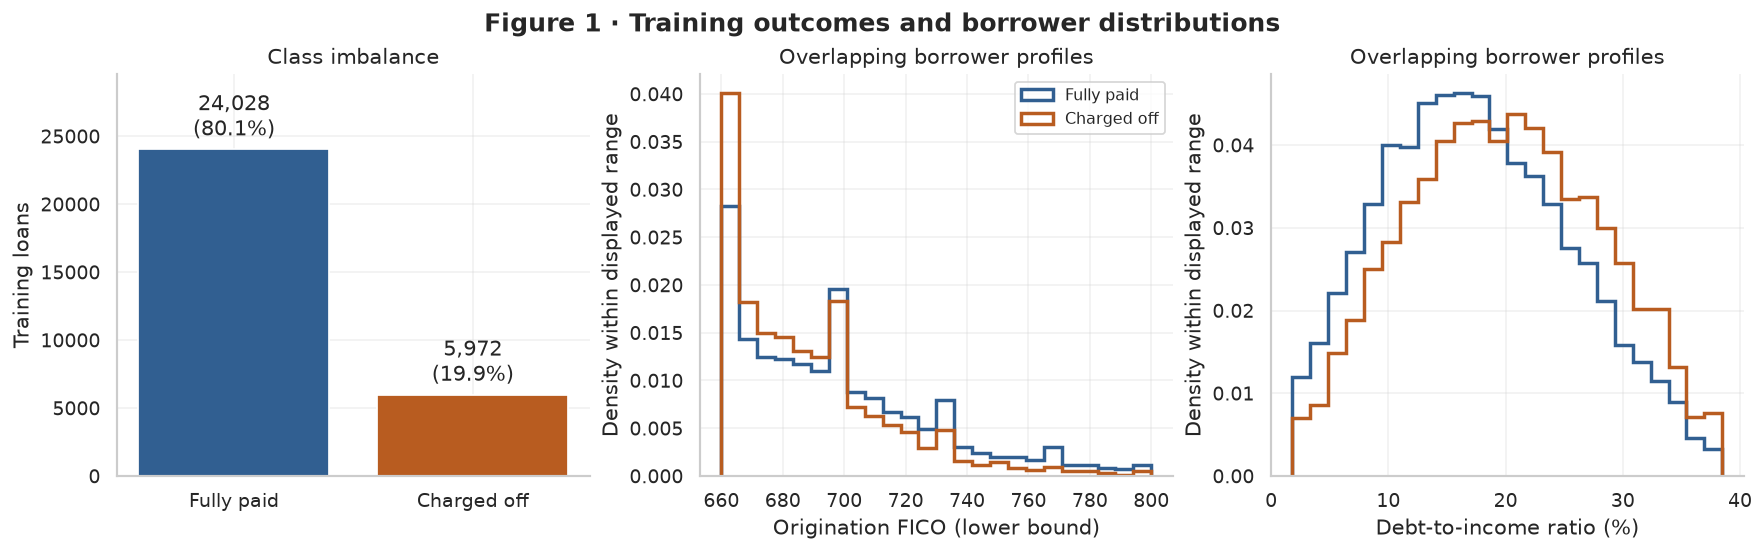

Feature 1,Feature 2,Correlation
open_acc,total_acc,0.702
fico_range_low,revol_util,-0.467
loan_amnt,revol_bal,0.306
loan_amnt,annual_inc,0.282
dti,open_acc,0.264


**What I see:** 19.9% of the training loans were charged off. Predicting Fully Paid for every loan would be 80.1% accurate and catch none of the charged-off loans. The strongest numeric correlation is between `open_acc` and `total_acc` (0.702). That is a reason to be careful with coefficient interpretation.

In [31]:
missing_table = X_train.isna().mean().mul(100).rename("Missing (%)").rename_axis("Feature").reset_index().sort_values("Missing (%)", ascending=False)
show_table(missing_table.head(8), 2)
missing_table.to_csv(OUTPUT_DIR / "training_missingness.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), layout="constrained")
counts = y_train.value_counts().reindex([0, 1])
bars = axes[0].bar(["Fully paid", "Charged off"], counts, color=[BLUE, ORANGE])
axes[0].bar_label(bars, labels=[f"{v:,}\n({v / len(y_train):.1%})" for v in counts], padding=4)
axes[0].set(ylim=(0, counts.max()*1.23), ylabel="Training loans", title="Class imbalance")
for ax, col, label in zip(axes[1:], ["fico_range_low", "dti"], ["Origination FICO (lower bound)", "Debt-to-income ratio (%)"]):
    low, high = X_train[col].quantile([0.01, 0.99])
    bins = np.linspace(low, high, 25)
    for target, color, name in [(0, BLUE, "Fully paid"), (1, ORANGE, "Charged off")]:
        values = X_train.loc[y_train.eq(target), col].dropna()
        ax.hist(values, bins=bins, density=True, histtype="step", linewidth=2, color=color, label=name)
    ax.set(xlabel=label, ylabel="Density within displayed range", title="Overlapping borrower profiles")
axes[1].legend(fontsize=9)
fig.suptitle("Figure 1 · Training outcomes and borrower distributions", fontweight="bold")
finish(fig, "figure_1_training_eda")

corr = X_train[numeric_cols].corr()
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().rename("Correlation").reset_index()
pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
pairs = pairs.iloc[np.argsort(-pairs["Correlation"].abs().to_numpy())].reset_index(drop=True)
show_table(pairs.head(5))
display(Markdown(f"**What I see:** {y_train.mean():.1%} of the training loans were charged off. "
    f"Predicting Fully Paid for every loan would be {1-y_train.mean():.1%} accurate and catch none of the charged-off loans. "
    f"The strongest numeric correlation is between `{pairs.iloc[0]['Feature 1']}` and `{pairs.iloc[0]['Feature 2']}` "
    f"({pairs.iloc[0]['Correlation']:.3f}). That is a reason to be careful with coefficient interpretation."))

## 5. Why Logistic Regression and Scaling Matter

Logistic regression fits this assignment because the target has two outcomes. It estimates the probability that a loan will be charged off.

Unlike ordinary linear regression, logistic regression keeps predicted probabilities between 0 and 1. A probability threshold then determines whether the loan is classified as Fully Paid or Charged Off.

I compare three approaches:

| Approach | What it does |
|---|---|
| No scaling | Keeps numeric features in their original units |
| Standardization | Centers nonconstant training features at 0 with a standard deviation of 1 |
| Min-max scaling | Places nonconstant training features between 0 and 1 |

Income, loan amount, FICO, and account counts have different units and ranges. Scaling makes those numeric units more comparable, can help the model converge, and changes how regularization affects the coefficients.

Scaling does not guarantee better predictions or make every feature equally important. It also does not remove outliers.

The scaling figure shows that most incomes become compressed near zero under min-max scaling because the largest income is much higher than typical values. Standardization gives the middle of the distribution more room, although extreme values still affect it.

I scale numeric features only. The categorical indicators remain coded as 0 or 1.

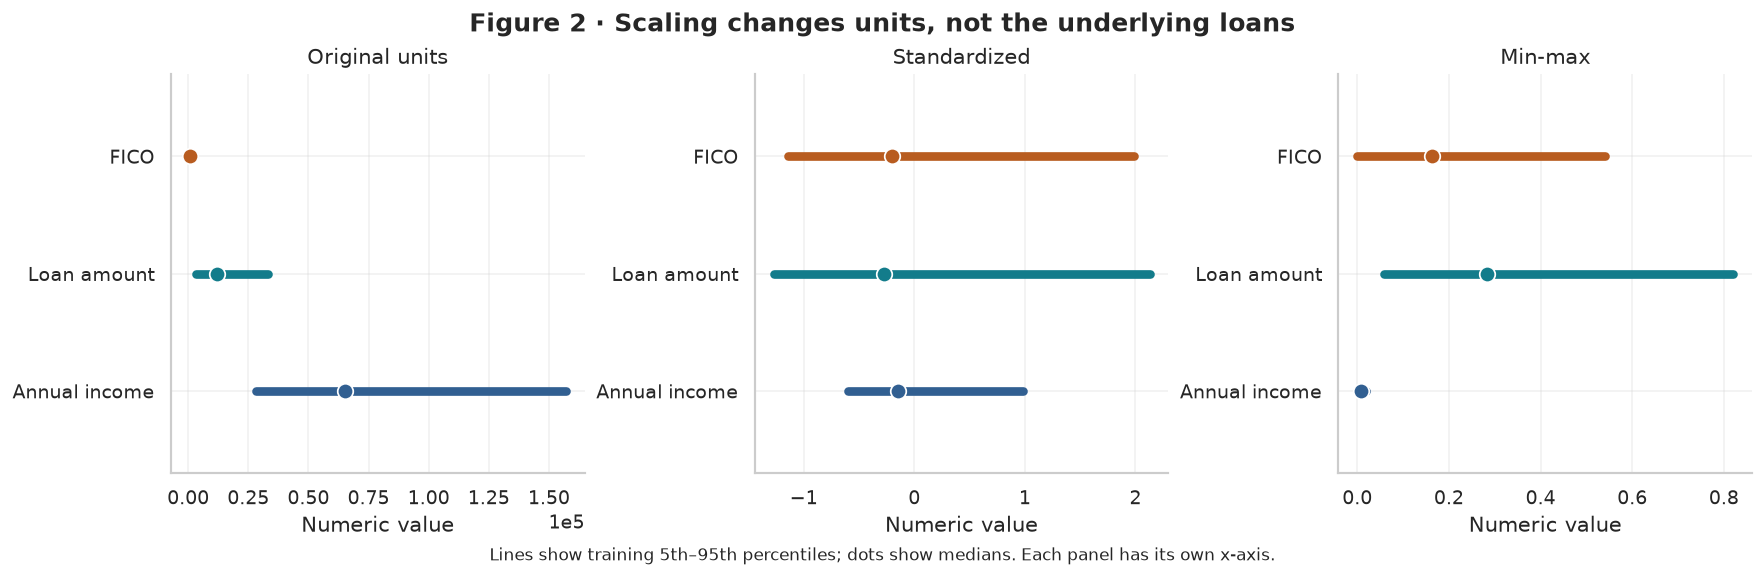

Method,Feature,Mean,SD (ddof=0),Minimum,Maximum
Original units,annual_inc,"76,975.387","81,129.163",0.000,"8,400,000.000"
Original units,loan_amnt,"14,419.173","8,735.885","1,000.000","40,000.000"
Original units,fico_range_low,696.394,31.990,660.000,845.000
Standardized,annual_inc,0.000,1.000,-0.949,102.590
Standardized,loan_amnt,-0.000,1.000,-1.536,2.928
Standardized,fico_range_low,0.000,1.000,-1.138,4.645
Min-max,annual_inc,0.009,0.010,0.000,1.000
Min-max,loan_amnt,0.344,0.224,0.000,1.000
Min-max,fico_range_low,0.197,0.173,0.000,1.000


In [32]:
# Visual demonstration only: fit on training values and keep the same observations in all panels.
demo_cols = ["annual_inc", "loan_amnt", "fico_range_low"]
demo = SimpleImputer(strategy="median").fit_transform(X_train[demo_cols])
demo_versions = {"Original units": demo,
                 "Standardized": StandardScaler().fit_transform(demo),
                 "Min-max": MinMaxScaler().fit_transform(demo)}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout="constrained")
for ax, (name, values) in zip(axes, demo_versions.items()):
    for j, color in enumerate([BLUE, TEAL, ORANGE]):
        lo, median, hi = np.quantile(values[:, j], [0.05, 0.5, 0.95])
        ax.plot([lo, hi], [j, j], color=color, linewidth=5, solid_capstyle="round")
        ax.scatter(median, j, color=color, edgecolor="white", s=80, zorder=3)
    ax.set(yticks=range(3), yticklabels=["Annual income", "Loan amount", "FICO"],
           title=name, xlabel="Numeric value", ylim=(-0.7, 2.7))
    ax.ticklabel_format(axis="x", style="sci", scilimits=(-3, 4))
fig.suptitle("Figure 2 · Scaling changes units, not the underlying loans", fontweight="bold")
fig.supxlabel("Lines show training 5th–95th percentiles; dots show medians. Each panel has its own x-axis.", fontsize=10)
finish(fig, "figure_2_scaling")
scale_summary = pd.DataFrame([{"Method": name, "Feature": col,
    "Mean": values[:, j].mean(), "SD (ddof=0)": values[:, j].std(),
    "Minimum": values[:, j].min(), "Maximum": values[:, j].max()}
    for name, values in demo_versions.items() for j, col in enumerate(demo_cols)])
show_table(scale_summary)

## 6. Model Selection and Regularization

I first compare the three scaling approaches using the same cross-validation folds and `C = 1`.

Then I test `C` values of **0.01, 0.1, 1, and 10** for standardization and min-max scaling. Smaller values of `C` apply stronger regularization.

I select the converged scaled model with the highest average cross-validation ROC-AUC.

The selected model used **standardization with C = 10**. Its average cross-validation ROC-AUC was **0.692**.

The unscaled model reached the iteration limit in all five folds. Its lower score therefore reflects an unfinished optimization result, not proof that an unscaled model could never perform similarly.

At `C = 1`, standardization and min-max scaling differed by only about **0.0027 ROC-AUC**. That difference was small compared with the variation across folds, so I would not describe it as a decisive advantage.

In [33]:
def make_model(scaling, C=1.0):
    scaler = {"No scaling": "passthrough", "Standardization": StandardScaler(),
              "Min-max": MinMaxScaler()}[scaling]
    numeric = Pipeline([("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
                        ("scale", scaler)])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing", keep_empty_features=True)),
        ("encode", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))])
    prepare = ColumnTransformer([("num", numeric, numeric_cols),
                                 ("cat", categorical, categorical_cols)])
    # Omitting penalty uses L2 by default and avoids version-specific penalty deprecations.
    return Pipeline([("prepare", prepare), ("model", LogisticRegression(
        C=C, solver="lbfgs", max_iter=MAX_ITER, tol=1e-5, random_state=SEED))])

def evaluate_cv(scaling, C):
    records = []
    for fold, (fit_rows, holdout_rows) in enumerate(cv, 1):
        model = make_model(scaling, C)
        start = time.perf_counter()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            model.fit(X_train.iloc[fit_rows], y_train.iloc[fit_rows])
            prob = model.predict_proba(X_train.iloc[holdout_rows])[:, 1]
        target = y_train.iloc[holdout_rows]
        convergence = sum(issubclass(w.category, ConvergenceWarning) for w in caught)
        other = sorted(set(str(w.message) for w in caught if not issubclass(w.category, ConvergenceWarning)))
        records.append({"Scaling": scaling, "C": C, "Fold": fold,
            "ROC-AUC": roc_auc_score(target, prob), "Average precision": average_precision_score(target, prob),
            "Log loss": log_loss(target, prob), "Seconds": time.perf_counter()-start,
            "Iterations": int(model.named_steps["model"].n_iter_.max()),
            "Convergence warnings": convergence, "Other warnings": " | ".join(other)})
    return records

fold_records = []
for scaling in ["No scaling", "Standardization", "Min-max"]:
    print("Comparing", scaling, "at C=1", flush=True)
    fold_records.extend(evaluate_cv(scaling, 1.0))

def summarize_cv(records):
    return (pd.DataFrame(records).groupby(["Scaling", "C"], sort=False).agg(
        **{"CV ROC-AUC": ("ROC-AUC", "mean"), "Fold SD": ("ROC-AUC", "std"),
           "CV average precision": ("Average precision", "mean"), "CV log loss": ("Log loss", "mean"),
           "Mean seconds": ("Seconds", "mean"), "Mean iterations": ("Iterations", "mean"),
           "Convergence warnings": ("Convergence warnings", "sum")}).reset_index())

fixed_c_results = summarize_cv(fold_records)
show_table(fixed_c_results, 4)
for scaling in ["Standardization", "Min-max"]:
    for C in C_GRID:
        if C == 1.0:  # Already evaluated on these exact folds.
            continue
        print(f"Tuning {scaling}: C={C}", flush=True)
        fold_records.extend(evaluate_cv(scaling, C))
fold_results = pd.DataFrame(fold_records)
search_results = summarize_cv(fold_records)
candidate_results = search_results.loc[search_results["Scaling"].ne("No scaling")].copy()
eligible = candidate_results.loc[candidate_results["Convergence warnings"].eq(0)]
if eligible.empty:
    raise RuntimeError("No scaled candidate converged in all folds. Increase MAX_ITER and rerun before opening the test results.")
chosen = eligible.sort_values(["CV ROC-AUC", "CV log loss"], ascending=[False, True], kind="stable").iloc[0]
selected_scaling, selected_C = chosen["Scaling"], float(chosen["C"])
show_table(candidate_results.sort_values("CV ROC-AUC", ascending=False), 4)
print(f"Selected using training CV: {selected_scaling}, C={selected_C:g}")
fold_results.to_csv(OUTPUT_DIR / "cv_fold_results.csv", index=False)
search_results.to_csv(OUTPUT_DIR / "cv_search_results.csv", index=False)

Comparing No scaling at C=1
Comparing Standardization at C=1
Comparing Min-max at C=1


Scaling,C,CV ROC-AUC,Fold SD,CV average precision,CV log loss,Mean seconds,Mean iterations,Convergence warnings
No scaling,1.0000,0.6761,0.0073,0.3446,0.4676,2.8966,"2,000.0000",5
Standardization,1.0000,0.6921,0.0082,0.3594,0.4615,0.3501,169.0000,0
Min-max,1.0000,0.6894,0.0084,0.3568,0.4623,0.3012,123.2000,0


Tuning Standardization: C=0.01
Tuning Standardization: C=0.1
Tuning Standardization: C=10.0
Tuning Min-max: C=0.01
Tuning Min-max: C=0.1
Tuning Min-max: C=10.0


Scaling,C,CV ROC-AUC,Fold SD,CV average precision,CV log loss,Mean seconds,Mean iterations,Convergence warnings
Standardization,10.0000,0.6922,0.0083,0.3591,0.4615,0.4626,270.0000,0
Standardization,1.0000,0.6921,0.0082,0.3594,0.4615,0.3501,169.0000,0
Min-max,10.0000,0.6919,0.0085,0.3586,0.4617,0.4416,233.8000,0
Standardization,0.1000,0.6918,0.0081,0.3597,0.4616,0.1837,79.0000,0
Standardization,0.0100,0.6915,0.0077,0.3600,0.4619,0.1471,32.2000,0
Min-max,1.0000,0.6894,0.0084,0.3568,0.4623,0.3012,123.2000,0
Min-max,0.1000,0.6818,0.0083,0.3499,0.4649,0.1802,63.2000,0
Min-max,0.0100,0.6699,0.0090,0.3396,0.4702,0.1246,27.8000,0


Selected using training CV: Standardization, C=10


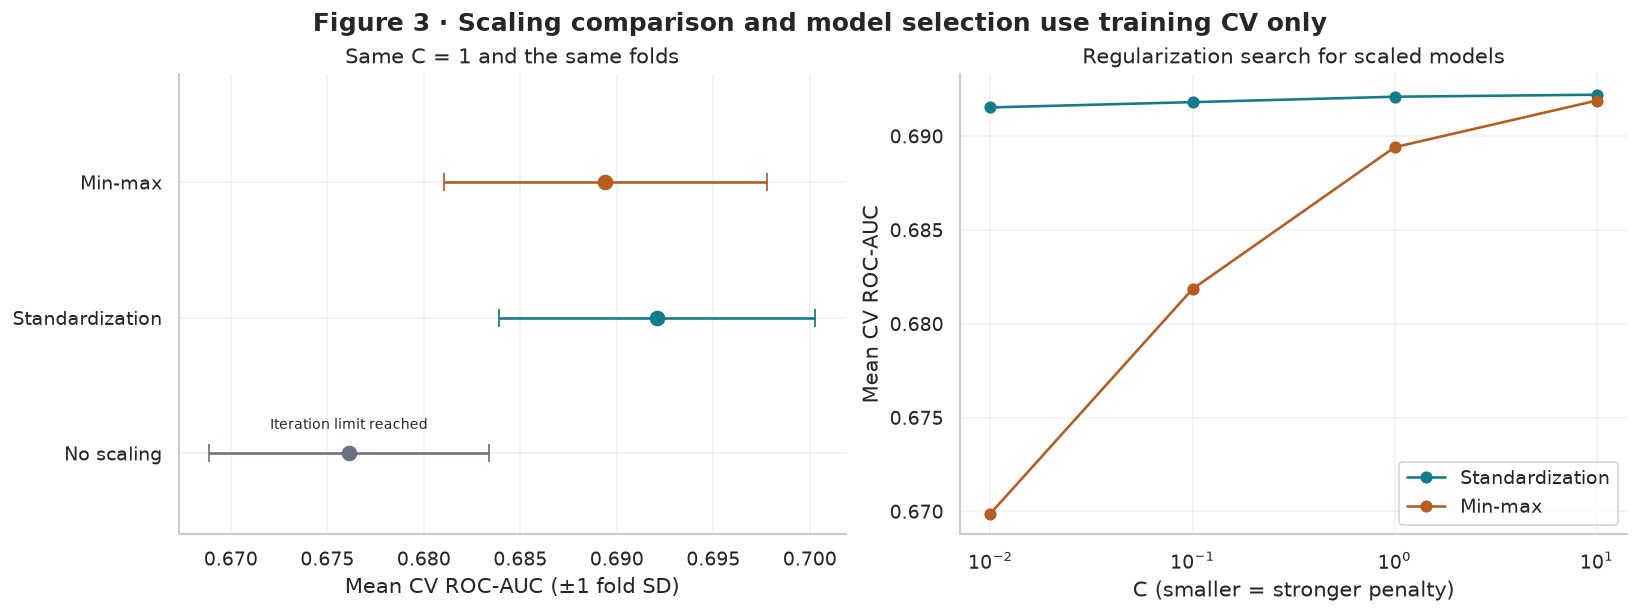

**What I see:** at C = 1, the standardization-minus-min-max ROC-AUC difference is +0.0027. The full search selects **Standardization, C = 10**, with mean CV ROC-AUC **0.692**. I compare the size of the differences with the fold variation before calling one approach meaningfully better.

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
for i, row in fixed_c_results.reset_index(drop=True).iterrows():
    axes[0].errorbar(row["CV ROC-AUC"], i, xerr=row["Fold SD"], fmt="o", capsize=5,
                     color=[GRAY, TEAL, ORANGE][i], markersize=8)
    if row["Convergence warnings"]:
        axes[0].annotate("Iteration limit reached", (row["CV ROC-AUC"], i),
                         xytext=(0, 14), textcoords="offset points", fontsize=8, ha="center")
axes[0].set(yticks=range(3), yticklabels=fixed_c_results["Scaling"],
            xlabel="Mean CV ROC-AUC (±1 fold SD)", title="Same C = 1 and the same folds", ylim=(-0.6, 2.8))
for scaling, color in [("Standardization", TEAL), ("Min-max", ORANGE)]:
    group = candidate_results.loc[candidate_results["Scaling"].eq(scaling)].sort_values("C")
    axes[1].plot(group["C"], group["CV ROC-AUC"], marker="o", color=color, label=scaling)
axes[1].set(xscale="log", xlabel="C (smaller = stronger penalty)", ylabel="Mean CV ROC-AUC",
            title="Regularization search for scaled models")
axes[1].legend()
fig.suptitle("Figure 3 · Scaling comparison and model selection use training CV only", fontweight="bold")
finish(fig, "figure_3_cv_comparison")
delta = (fixed_c_results.set_index("Scaling").loc["Standardization", "CV ROC-AUC"]
         - fixed_c_results.set_index("Scaling").loc["Min-max", "CV ROC-AUC"])
display(Markdown(f"**What I see:** at C = 1, the standardization-minus-min-max ROC-AUC difference is {delta:+.4f}. "
    f"The full search selects **{selected_scaling}, C = {selected_C:g}**, with mean CV ROC-AUC "
    f"**{chosen['CV ROC-AUC']:.3f}**. I compare the size of the differences with the fold variation before calling one approach meaningfully better."))

## 7. Choosing the Probability Threshold

The default classification threshold is 0.50. However, this may miss many charged off loans when most predicted probabilities are below 50%.

I compare thresholds using validation data and select the one with the highest charged off F1 score. The selected threshold was **0.20**.

The main measures are:

- **Precision:** Of the loans flagged, how many were charged off?
- **Recall:** Of all charged off loans, how many did the model identify?
- **F1:** How well does the model balance precision and recall?

A lower threshold can identify more charged-off loans, but it can also flag more borrowers who would repay. Selecting the threshold is therefore a decision about the tradeoff between these errors.

The threshold is chosen before evaluating the test set.

Threshold,Precision,Recall,F1
0.200,0.306,0.621,0.410
0.500,0.460,0.046,0.083


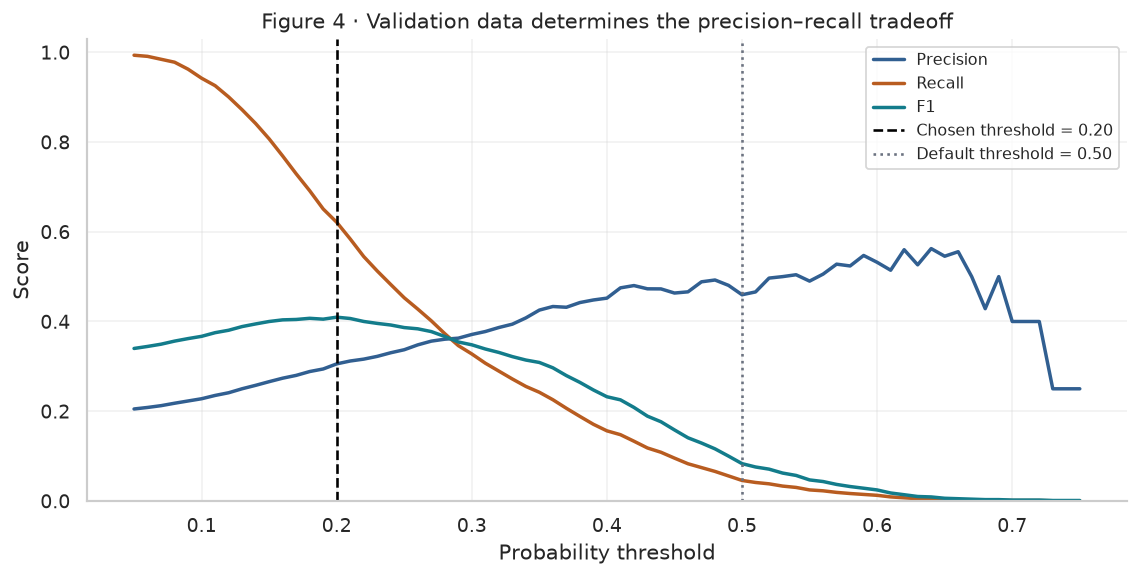

Model and threshold are now frozen: Standardization, C=10, threshold=0.20


In [35]:
selected_model = make_model(selected_scaling, selected_C)
with warnings.catch_warnings(record=True) as final_warnings:
    warnings.simplefilter("always")
    selected_model.fit(X_train, y_train)
if any(issubclass(w.category, ConvergenceWarning) for w in final_warnings):
    raise RuntimeError("Final training fit did not converge; fix this before evaluating the test set.")
for w in final_warnings:
    print(str(w.message))
val_prob = selected_model.predict_proba(X_val)[:, 1]
threshold_results = pd.DataFrame([{"Threshold": float(t),
    "Precision": precision_score(y_val, val_prob >= t, zero_division=0),
    "Recall": recall_score(y_val, val_prob >= t),
    "F1": f1_score(y_val, val_prob >= t)} for t in np.round(np.arange(0.05, 0.751, 0.01), 2)])
best_threshold = float(threshold_results.sort_values(["F1", "Threshold"], ascending=[False, False]).iloc[0]["Threshold"])
show_table(threshold_results.loc[threshold_results["Threshold"].isin([0.5, best_threshold])], 3)
threshold_results.to_csv(OUTPUT_DIR / "validation_thresholds.csv", index=False)
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
for metric, color in [("Precision", BLUE), ("Recall", ORANGE), ("F1", TEAL)]:
    ax.plot(threshold_results["Threshold"], threshold_results[metric], label=metric, color=color, linewidth=2)
ax.axvline(best_threshold, ls="--", color="black", label=f"Chosen threshold = {best_threshold:.2f}")
ax.axvline(0.5, ls=":", color=GRAY, label="Default threshold = 0.50")
ax.set(xlabel="Probability threshold", ylabel="Score", ylim=(0, 1.03),
       title="Figure 4 · Validation data determines the precision–recall tradeoff")
ax.legend(loc="best", fontsize=9)
finish(fig, "figure_4_threshold")
print(f"Model and threshold are now frozen: {selected_scaling}, C={selected_C:g}, threshold={best_threshold:.2f}")

## 8. Final Test Results

The selected model achieved a test **ROC-AUC of 0.702** and **average precision of 0.381**.

For comparison, the constant baseline had a ROC-AUC of 0.500 and average precision of 0.199.

Changing the threshold produced a substantial difference in classification results:

| Metric | Threshold 0.50 | Threshold 0.20 |
|---|---:|---:|
| Accuracy | 80.7% | 64.8% |
| Charged-off precision | 62.2% | 31.2% |
| Charged-off recall | 7.5% | 63.8% |
| Charged-off F1 | 0.134 | 0.419 |

At the selected threshold, the model identified **1,270 charged-off loans**, missed **720**, and incorrectly flagged **2,795 fully paid loans**.

The lower threshold improved detection, but the increase in false alarms was substantial. This explains why the lower accuracy does not tell the whole story.

Changing the threshold did not change ROC-AUC or average precision because the underlying predicted probabilities stayed the same.

Model / decision rule,Threshold,Accuracy,Balanced accuracy,Precision,Recall,F1
Majority baseline,0.500,0.801,0.500,0.000,0.000,0.000
Logistic / default,0.500,0.807,0.532,0.622,0.075,0.134
Logistic / selected,0.200,0.648,0.645,0.312,0.638,0.419


Model / decision rule,ROC-AUC,Average precision,Log loss,Brier
Majority baseline,0.500,0.199,0.499,0.159
Logistic / default,0.702,0.381,0.459,0.145
Logistic / selected,0.702,0.381,0.459,0.145


Split,ROC-AUC,Average precision,Log loss
Training (in-sample),0.695,0.362,0.460
Validation,0.688,0.345,0.464
Test,0.702,0.381,0.459


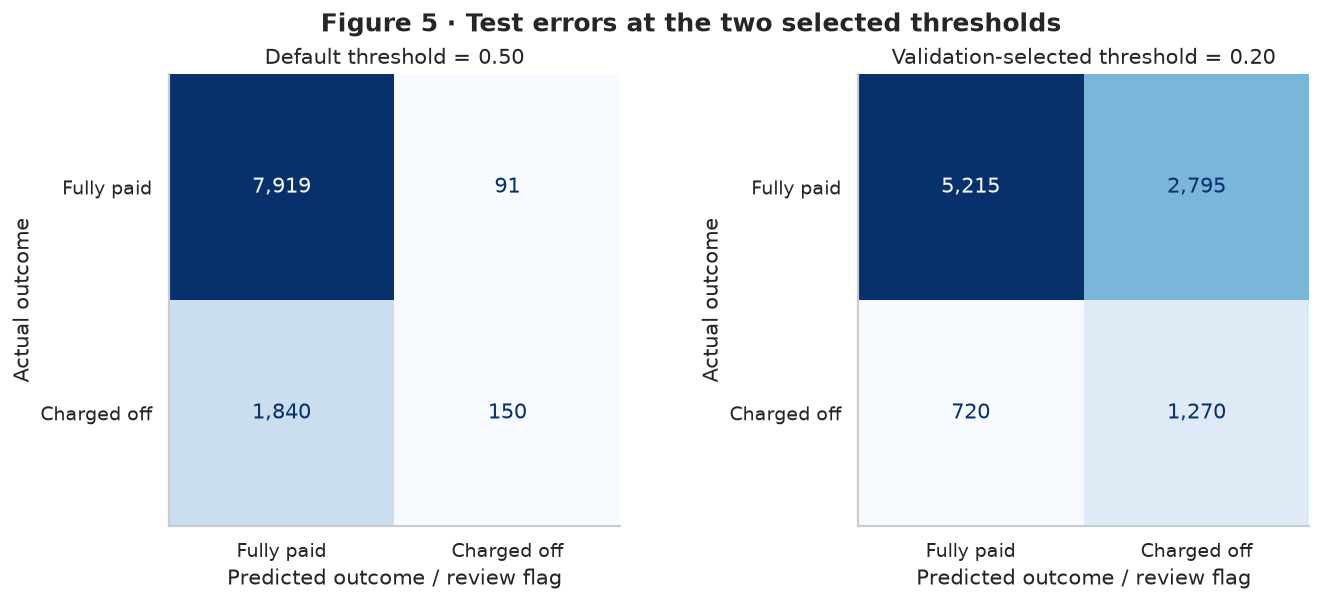

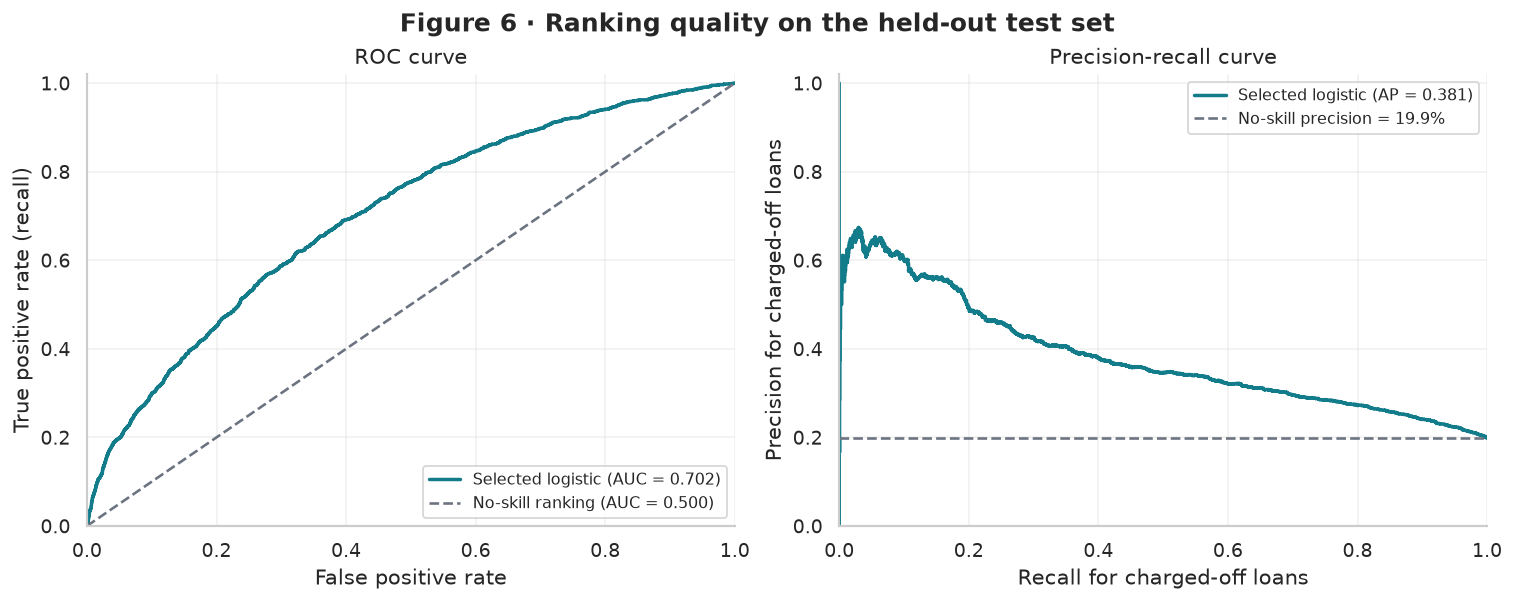

Evaluation complete. Tables and figures saved to: week4_outputs


In [36]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Close any unfinished figures from the previous attempt.
plt.close("all")


# 1. Generate probabilities using the already-selected model
# 

test_prob = selected_model.predict_proba(X_test)[:, 1]
train_prob = selected_model.predict_proba(X_train)[:, 1]
val_prob = selected_model.predict_proba(X_val)[:, 1]

dummy = DummyClassifier(strategy="prior").fit(X_train, y_train)
baseline_prob = dummy.predict_proba(X_test)[:, 1]


# 2. Calculate evaluation metrics

def metric_row(name, target, prob, threshold):
    pred = (prob >= threshold).astype(int)

    return {
        "Model / decision rule": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(target, pred),
        "Balanced accuracy": balanced_accuracy_score(target, pred),
        "Precision": precision_score(target, pred, zero_division=0),
        "Recall": recall_score(target, pred, zero_division=0),
        "F1": f1_score(target, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(target, prob),
        "Average precision": average_precision_score(target, prob),
        "Log loss": log_loss(target, prob),
        "Brier": brier_score_loss(target, prob),
    }


test_results = pd.DataFrame([
    metric_row(
        "Majority baseline",
        y_test,
        baseline_prob,
        0.50,
    ),
    metric_row(
        "Logistic / default",
        y_test,
        test_prob,
        0.50,
    ),
    metric_row(
        "Logistic / selected",
        y_test,
        test_prob,
        best_threshold,
    ),
])

show_table(test_results[[
    "Model / decision rule",
    "Threshold",
    "Accuracy",
    "Balanced accuracy",
    "Precision",
    "Recall",
    "F1",
]])

show_table(test_results[[
    "Model / decision rule",
    "ROC-AUC",
    "Average precision",
    "Log loss",
    "Brier",
]])


# 3. Compare training, validation, and test performance


gap_table = pd.DataFrame([
    {
        "Split": name,
        "ROC-AUC": roc_auc_score(target, prob),
        "Average precision": average_precision_score(target, prob),
        "Log loss": log_loss(target, prob),
    }
    for name, target, prob in [
        ("Training (in-sample)", y_train, train_prob),
        ("Validation", y_val, val_prob),
        ("Test", y_test, test_prob),
    ]
])

show_table(gap_table)


# 4. Save results

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

test_results.to_csv(
    OUTPUT_DIR / "test_metrics.csv",
    index=False,
)

gap_table.to_csv(
    OUTPUT_DIR / "generalization_scores.csv",
    index=False,
)

test_predictions = pd.DataFrame({
    "source_row": loans.loc[
        X_test.index, "source_row"
    ].to_numpy(),
    "observed_charged_off": y_test.to_numpy(),
    "predicted_probability": test_prob,
    "selected_prediction": (
        test_prob >= best_threshold
    ).astype(int),
})

test_predictions.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)



# 5. Confusion matrices

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4.7),
    layout="constrained",
)

threshold_settings = [
    (axes[0], 0.50, "Default"),
    (axes[1], best_threshold, "Validation-selected"),
]

for ax, threshold, title in threshold_settings:
    predictions = (test_prob >= threshold).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["Fully paid", "Charged off"],
        cmap="Blues",
        values_format=",d",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(f"{title} threshold = {threshold:.2f}")
    ax.set_xlabel("Predicted outcome / review flag")
    ax.set_ylabel("Actual outcome")
    ax.grid(False)

fig.suptitle(
    "Figure 5 · Test errors at the two selected thresholds",
    fontweight="bold",
)

finish(fig, "figure_5_confusion_matrices")


# 6. Calculate ROC and precision-recall curves

fpr, tpr, _ = roc_curve(
    y_test,
    test_prob,
    pos_label=1,
)

pr_precision, pr_recall, _ = precision_recall_curve(
    y_test,
    test_prob,
    pos_label=1,
)

test_auc = roc_auc_score(y_test, test_prob)
test_ap = average_precision_score(y_test, test_prob)
test_prevalence = float(y_test.mean())


# 7. Plot curves directly with Matplotlib

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.7),
    layout="constrained",
)

# ROC curve
axes[0].plot(
    fpr,
    tpr,
    color=TEAL,
    linewidth=2,
    label=f"Selected logistic (AUC = {test_auc:.3f})",
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=GRAY,
    label="No-skill ranking (AUC = 0.500)",
)

axes[0].set(
    title="ROC curve",
    xlabel="False positive rate",
    ylabel="True positive rate (recall)",
    xlim=(0, 1),
    ylim=(0, 1.02),
)

axes[0].legend(loc="lower right", fontsize=9)

# Precision-recall curve
axes[1].step(
    pr_recall,
    pr_precision,
    where="post",
    color=TEAL,
    linewidth=2,
    label=f"Selected logistic (AP = {test_ap:.3f})",
)

axes[1].axhline(
    test_prevalence,
    linestyle="--",
    color=GRAY,
    label=f"No-skill precision = {test_prevalence:.1%}",
)

axes[1].set(
    title="Precision-recall curve",
    xlabel="Recall for charged-off loans",
    ylabel="Precision for charged-off loans",
    xlim=(0, 1),
    ylim=(0, 1.02),
)

axes[1].legend(loc="upper right", fontsize=9)

fig.suptitle(
    "Figure 6 · Ranking quality on the held-out test set",
    fontweight="bold",
)

finish(fig, "figure_6_ranking_curves")

print("Evaluation complete. Tables and figures saved to:", OUTPUT_DIR)

## 9. Interpreting the Coefficients

Higher FICO and income had negative coefficients in the selected model, while debt-to-income ratio and loan amount had positive coefficients.

These signs describe associations when the other modeled features are held constant. They do not prove that changing a feature would cause repayment behavior to change.

For standardized numeric features, each coefficient represents the change in log-odds associated with a one-training-standard-deviation increase.

Open accounts and total accounts had coefficients with opposite signs. Because those features are correlated, I would be cautious about interpreting either coefficient by itself.

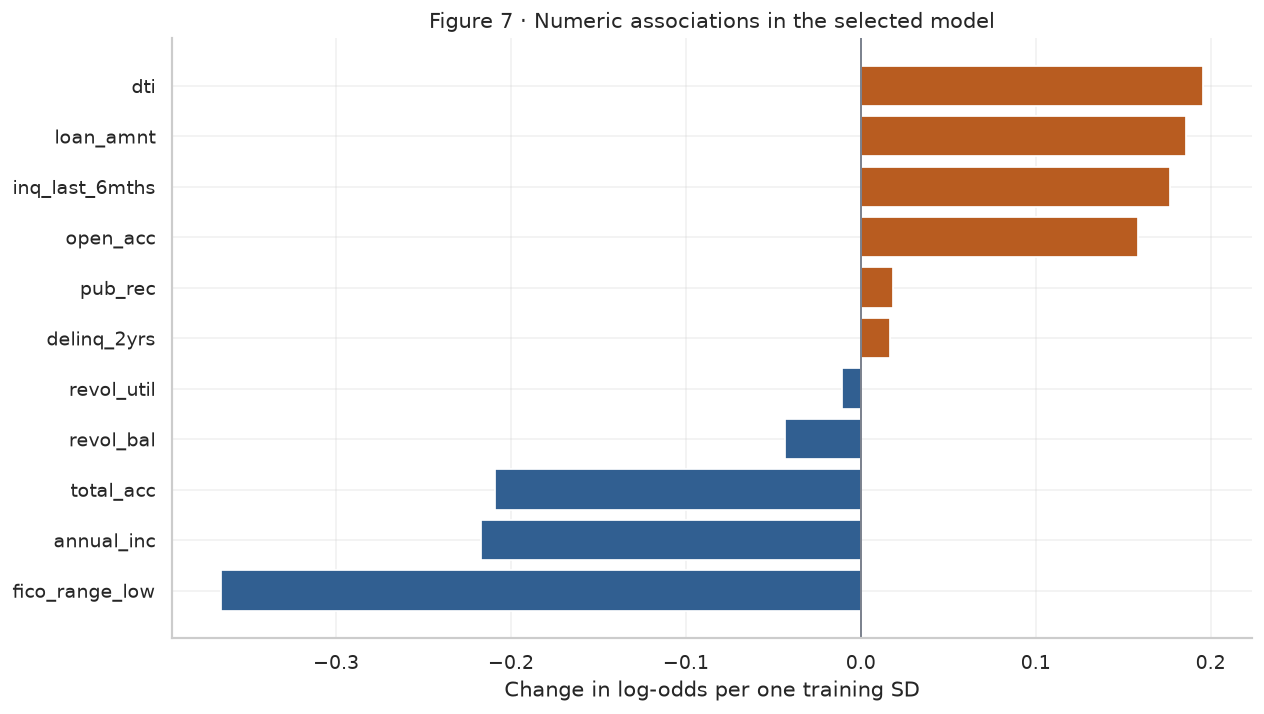

Feature,Coefficient,Odds multiplier
fico_range_low,-0.3657,0.6937
annual_inc,-0.2173,0.8047
total_acc,-0.2093,0.8112
revol_bal,-0.0432,0.9577
revol_util,-0.0105,0.9895
delinq_2yrs,0.0168,1.0170
pub_rec,0.0185,1.0187
open_acc,0.1583,1.1715
inq_last_6mths,0.1770,1.1936
loan_amnt,0.1861,1.2046


Categorical feature,Reference category
term,36 months
home_ownership,ANY
purpose,car
emp_length,1 year


Feature,Coefficient,Odds multiplier
cat__purpose_renewable_energy,1.8174,6.1555
cat__purpose_educational,1.7937,6.0119
cat__home_ownership_RENT,1.1751,3.2384
cat__home_ownership_OTHER,1.1396,3.1256
cat__home_ownership_OWN,1.0218,2.7782
cat__term_60 months,0.9437,2.5695
cat__home_ownership_MORTGAGE,0.7741,2.1687
cat__purpose_moving,0.6967,2.0072


In [37]:
prepare = selected_model.named_steps["prepare"]
coef = selected_model.named_steps["model"].coef_[0]
names = prepare.get_feature_names_out()
coef_table = pd.DataFrame({"Feature": names, "Coefficient": coef, "Odds multiplier": np.exp(coef)})
coef_table.to_csv(OUTPUT_DIR / "model_coefficients.csv", index=False)
numeric_coefs = coef_table.iloc[:len(numeric_cols)].copy()
numeric_coefs["Feature"] = numeric_cols
numeric_coefs = numeric_coefs.sort_values("Coefficient")
fig, ax = plt.subplots(figsize=(10, 5.6), layout="constrained")
ax.barh(numeric_coefs["Feature"], numeric_coefs["Coefficient"],
        color=[ORANGE if v > 0 else BLUE for v in numeric_coefs["Coefficient"]])
ax.axvline(0, color=GRAY, linewidth=1)
unit_label = "one training SD" if selected_scaling == "Standardization" else "one training min–max span"
ax.set(xlabel=f"Change in log-odds per {unit_label}", ylabel="",
       title="Figure 7 · Numeric associations in the selected model")
finish(fig, "figure_7_coefficients")
show_table(numeric_coefs, 4)
encoder = prepare.named_transformers_["cat"].named_steps["encode"]
references = {col: str(categories[index]) for col, categories, index in
              zip(categorical_cols, encoder.categories_, encoder.drop_idx_)}
show_table(pd.DataFrame(references.items(), columns=["Categorical feature", "Reference category"]))
show_table(coef_table.iloc[len(numeric_cols):].assign(
    Magnitude=lambda frame: frame["Coefficient"].abs()).sort_values("Magnitude", ascending=False)
    .drop(columns="Magnitude").head(8), 4)

## 10. What I Learned

The biggest takeaway for me was how much accuracy can hide. At the default threshold of 0.50, the model was about **80.7% accurate**, but it identified only **7.5% of charged-off loans**. For my capstone, that would leave most of the loans I am trying to identify undetected.

Using the validation-selected threshold of **0.20** increased charged-off recall to **63.8%**, with an **F1 score of 0.419**. However, precision dropped to **31.2%**, meaning most flagged loans were actually fully paid. The model caught more charged-off loans, but it also created more false alarms. Whether that tradeoff is acceptable would depend on how the lender uses the predictions and the cost of each mistake.

Scaling also helped the model finish fitting. The unscaled approach reached the iteration limit in all five folds, while standardization and min-max scaling converged. Standardization with **C = 10** had the highest average cross-validation ROC-AUC, but its advantage over the other scaled settings was small. I would not describe that as a major improvement.

The final test **ROC-AUC was 0.702**, compared with **0.500** for the baseline. The borrower and loan features provided useful information, but the results still leave room for improvement. This supports the main point in my proposal: I need to look at how well the model identifies charged-off loans and how often it incorrectly flags borrowers who repay.


### Limits and Next Steps

This analysis only includes accepted loans labeled Fully Paid or Charged Off. It does not represent rejected applicants, and excluding unresolved loans may leave out newer loans whose outcomes are not yet known.

The random split is another limitation. Loans in the training and test sets may come from similar economic periods, so these results do not show how well the model would perform on future loans. Borrower identifiers were also unavailable, which prevented me from fully checking whether the same borrower appeared more than once.

Logistic regression may miss nonlinear relationships and interactions between features. Scaling does not fix that, and it does not remove the effect of extreme values such as unusually high incomes. The coefficients also describe associations rather than causes.

My next step would be to test on later loan periods and compare logistic regression with tree-based models using the same data and split rules. I would also examine the income outliers and test transformations using development data. Before choosing a threshold for actual lending decisions, I would need to consider loan losses, the cost of unnecessary flags, probability calibration, and whether performance differs across borrower groups.